In [1]:
!pip install transformers trl peft datasets accelerate bitsandbytes sacrebleu bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.5 MB/s eta 0:00:00


In [2]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
from sacrebleu.metrics import BLEU
from bert_score import score as bert_score

In [3]:
# Loading model
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="auto"
)
model.eval()
print("Model loaded!")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded!


In [4]:
prompts = [
    "Explain the water cycle in simple terms.",
    "Write a short email declining a meeting politely.",
    "What are three benefits of regular exercise?",
    "Summarize what the internet is in two sentences.",
    "Give five tips for better time management.",
    "What is the difference between a virus and a bacteria?",
    "Write a short thank you note after a job interview.",
    "Explain what inflation means in simple terms.",
    "What are the pros and cons of social media?",
    "How does a search engine like Google work?"
]

gold_answers = [
    """
    The water cycle is the process of how water moves around the Earth again and again. It has four main steps:

Evaporation – The sun heats water in oceans, rivers, and lakes, turning it into water vapor that rises into the air.
Condensation – The water vapor cools in the sky and forms tiny droplets, creating clouds.
Precipitation – When the clouds get heavy, water falls back to Earth as rain, snow, or hail.
Collection – The water gathers in rivers, lakes, oceans, and the ground, and the cycle starts again.

In short:
Sun heats water → water rises → clouds form → rain falls → water collects again.
""",

"""    
Subject: Unable to Attend Meeting    
Dear [Name],

Thank you for the invitation. Unfortunately, I won’t be able to attend the meeting due to a prior commitment.

I appreciate your understanding and hope we can connect another time.

Best regards,
[Your Name]
""",

"""
Three benefits of regular exercise are:

Improves physical health – It helps keep your heart, muscles, and bones strong.
Boosts mental health – Exercise can reduce stress and improve mood.
Increases energy levels – Regular activity helps you feel more active and less tired.
""",

"""
The internet is a global network that connects computers and devices around the world so they can share information. It allows people to communicate, search for information, watch videos, shop online, and use many digital services.
""",

"""
1. Make a daily schedule – Plan your tasks before starting the day.


2. Set priorities – Focus on the most important tasks first.


3. Avoid distractions – Limit phone use and unnecessary social media.


4. Take short breaks – Breaks help you stay focused and productive.


5. Set deadlines – Giving yourself time limits helps you finish work on time.


""",

"""
A bacteria is a living single-celled organism that can survive on its own, while a virus is much smaller and needs a living host cell to reproduce.

Bacteria can sometimes be helpful, like those in our stomach, and many bacterial infections can be treated with antibiotics. Viruses usually cause illnesses like the flu or COVID-19, and antibiotics do not work against them.
""",

"""
Dear [Interviewer’s Name],

Thank you for taking the time to interview me today. I enjoyed learning more about the role and your team.

I appreciate the opportunity and look forward to hearing from you.

Best regards,
[Your Name]
""",

"""
Inflation means that the prices of goods and services increase over time, so money buys less than before. For example, if a burger costs $5 today and $6 next year, that increase in price is inflation.
""",

"""
Pros of Social Media
1. Easy communication – Helps people stay connected with friends and family.
2. Quick access to information – News, learning resources, and updates are easily available.
3. Business and marketing opportunities – Companies and individuals can promote products and services online.
Cons of Social Media
1. Can be distracting – Too much use may waste time and reduce productivity.
2. Privacy concerns – Personal information can sometimes be misused.
3. Mental health effects – Excessive use may lead to stress, anxiety, or low self-esteem.
""",

"""
A search engine like Google works in three main steps:

1. Crawling – It sends out automated programs called “bots” or “spiders” to visit websites and collect information.
2. Indexing – The information from websites is organized and stored in a huge database called an index.
3. Ranking – When you search for something, the search engine quickly looks through its index and shows the most relevant results based on keywords, quality, popularity, and other factors.

In simple terms, a search engine scans the internet, stores information, and helps you find the best matching websites for your search.
"""    
    
]

In [5]:
# Function to Generate Response from Model
def generate_response(prompt, model, tokenizer, max_new_tokens=200):
    # Format prompt in chat style that TinyLlama understands
    chat = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(
        chat,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,        # greedy decoding = consistent results
            pad_token_id=tokenizer.eos_token_id
        )

    # Decode only the new tokens (not the prompt)
    generated = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

In [6]:
# Run Base Model on All 10 Prompts
print("Running base model on 10 prompts...\n")

base_responses = []
for i, prompt in enumerate(prompts):
    response = generate_response(prompt, model, tokenizer)
    base_responses.append(response)
    print(f"✅ Prompt {i+1} done")
    print(f"   Response: {response[:100]}...")  # preview first 100 chars
    print()

Running base model on 10 prompts...

✅ Prompt 1 done
   Response: The water cycle is a continuous process that involves the movement of water from the atmosphere, oce...

✅ Prompt 2 done
   Response: Subject: Request for Rescheduling Meeting

Dear [Recipient],

I am writing to request a rescheduling...

✅ Prompt 3 done
   Response: 1. Improved cardiovascular health: Regular exercise helps to improve blood flow, reduce blood pressu...

✅ Prompt 4 done
   Response: The internet is a global network of interconnected computers, servers, and devices that allow people...

✅ Prompt 5 done
   Response: 1. Set realistic goals: Start by setting achievable goals that align with your priorities and schedu...

✅ Prompt 6 done
   Response: A virus and a bacteria are two different types of microorganisms.

1. Virus: A virus is a small, env...

✅ Prompt 7 done
   Response: Dear [Company Name],

I am writing to express my sincere gratitude for the opportunity to interview ...

✅ Prompt 8 done
   Respon

In [7]:
# Calculating BLEU + BERTScore
# --- BLEU Score ---
bleu = BLEU(effective_order=True)

bleu_scores = []
for ref, hyp in zip(gold_answers, base_responses):
    result = bleu.sentence_score(hypothesis=hyp, references=[ref])
    bleu_scores.append(round(result.score, 2))

# --- BERTScore ---
P, R, F1 = bert_score(
    cands=base_responses,
    refs=gold_answers,
    lang="en",
    verbose=False
)
bert_scores = [round(f.item(), 4) for f in F1]

print("BLEU Scores:", bleu_scores)
print("BERTScores (F1):", bert_scores)
print(f"\nAverage BLEU: {sum(bleu_scores)/len(bleu_scores):.2f}")
print(f"Average BERTScore: {sum(bert_scores)/len(bert_scores):.4f}")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BLEU Scores: [12.43, 7.05, 1.88, 20.44, 7.85, 5.0, 2.62, 2.28, 3.8, 4.09]
BERTScores (F1): [0.8706, 0.8783, 0.8834, 0.9434, 0.8988, 0.8606, 0.865, 0.8598, 0.8605, 0.8652]

Average BLEU: 6.74
Average BERTScore: 0.8786


In [8]:
# Display as a Clean Table
df = pd.DataFrame({
    "Prompt": [p[:50] + "..." for p in prompts],
    "Base Model Response": [r[:80] + "..." for r in base_responses],
    "BLEU": bleu_scores,
    "BERTScore (F1)": bert_scores
})

pd.set_option('display.max_colwidth', None)
print(df.to_string(index=False))

                                               Prompt                                                                     Base Model Response  BLEU  BERTScore (F1)
          Explain the water cycle in simple terms....     The water cycle is a continuous process that involves the movement of water from... 12.43          0.8706
 Write a short email declining a meeting politely.... Subject: Request for Rescheduling Meeting\n\nDear [Recipient],\n\nI am writing to re...  7.05          0.8783
      What are three benefits of regular exercise?...     1. Improved cardiovascular health: Regular exercise helps to improve blood flow,...  1.88          0.8834
  Summarize what the internet is in two sentences....     The internet is a global network of interconnected computers, servers, and devic... 20.44          0.9434
        Give five tips for better time management....     1. Set realistic goals: Start by setting achievable goals that align with your p...  7.85          0.8988
What is the diff

In [9]:
# Load & Preprocess Alpaca Dataset
from datasets import load_dataset

# Load Alpaca
alpaca = load_dataset("tatsu-lab/alpaca")

# Use only 5000 samples
alpaca_data = alpaca['train'].select(range(5000))

print(f"Dataset size: {len(alpaca_data)}")
print("Sample:", alpaca_data[0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Dataset size: 5000
Sample: {'instruction': 'Give three tips for staying healthy.', 'input': '', 'output': '1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nGive three tips for staying healthy.\n\n### Response:\n1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'}


In [10]:
# TinyLlama expects a specific format. This cell converts every sample:
def format_alpaca(sample):
    # If there's an input, include it. If not, skip it.
    if sample['input'].strip():
        prompt = f"### Instruction:\n{sample['instruction']}\n\n### Input:\n{sample['input']}\n\n### Response:\n{sample['output']}"
    else:
        prompt = f"### Instruction:\n{sample['instruction']}\n\n### Response:\n{sample['output']}"
    return {"text": prompt}

alpaca_formatted = alpaca_data.map(format_alpaca)
print("Formatted sample:")
print(alpaca_formatted[0]['text'])

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Formatted sample:
### Instruction:
Give three tips for staying healthy.

### Response:
1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.


In [22]:
# SFT Trial Function
from transformers import TrainingArguments, AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
import torch

def run_sft_trial(
    trial_name,
    dataset,
    # LoRA params
    lora_r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    # Training params
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    num_train_epochs=1,
    max_steps=-1  # -1 means use epochs
):
    print(f"\n{'='*50}")
    print(f"Starting Trial: {trial_name}")
    print(f"{'='*50}")

    # Load fresh base model for each trial
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.float16, 
        device_map="auto"
    )

    # LoRA config
    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    # Training config
    training_args = SFTConfig(
        output_dir=f"./{trial_name}",
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=per_device_train_batch_size,
        learning_rate=learning_rate,
        logging_steps=50,
        save_strategy="epoch",
        fp16=True,
        report_to="none"
    )

    # Trainer
    trainer = SFTTrainer(
        model=model,
        train_dataset=dataset,
        peft_config=lora_config,
        args=training_args,
    )

    # Train
    trainer.train()

    print(f"\nTrial {trial_name} complete!")
    return trainer, model, tokenizer

In [23]:
# Evaluate Model Function
import gc
from sacrebleu.metrics import BLEU
from bert_score import score as bert_score_fn

bleu_metric = BLEU(effective_order=True)

def evaluate_model(model, tokenizer, prompts, gold_answers, trial_name):
    model.eval()
    responses = []

    for prompt in prompts:
        response = generate_response(prompt, model, tokenizer)
        responses.append(response)

    # BLEU
    bleu_scores = []
    for ref, hyp in zip(gold_answers, responses):
        result = bleu_metric.sentence_score(hypothesis=hyp, references=[ref])
        bleu_scores.append(round(result.score, 2))

    # BERTScore
    P, R, F1 = bert_score_fn(cands=responses, refs=gold_answers, lang="en", verbose=False)
    bert_scores = [round(f.item(), 4) for f in F1]

    avg_bleu = round(sum(bleu_scores) / len(bleu_scores), 2)
    avg_bert = round(sum(bert_scores) / len(bert_scores), 4)

    print(f"\n📊 {trial_name} Results:")
    print(f"   Avg BLEU:      {avg_bleu}")
    print(f"   Avg BERTScore: {avg_bert}")

    return {
        "trial": trial_name,
        "responses": responses,
        "bleu_scores": bleu_scores,
        "bert_scores": bert_scores,
        "avg_bleu": avg_bleu,
        "avg_bert": avg_bert
    }

In [24]:
# TRIAL A1
alpaca_results = {}

trainer_a1, model_a1, tok_a1 = run_sft_trial(
    trial_name="alpaca_trial_A1",
    dataset=alpaca_formatted,
    lora_r=4,
    target_modules=["q_proj", "v_proj"],
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    num_train_epochs=1
)
alpaca_results["A1"] = evaluate_model(model_a1, tok_a1, prompts, gold_answers, "Alpaca Trial A1")
del model_a1, trainer_a1, tok_a1
torch.cuda.empty_cache()
gc.collect()


Starting Trial: alpaca_trial_A1


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


...


Trial alpaca_trial_A1 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Alpaca Trial A1 Results:
   Avg BLEU:      9.93
   Avg BERTScore: 0.8946


13593

In [25]:
# TRIAL A2
trainer_a2, model_a2, tok_a2 = run_sft_trial(
    trial_name="alpaca_trial_A2",
    dataset=alpaca_formatted,
    lora_r=8,
    target_modules=["q_proj", "v_proj"],
    learning_rate=1e-4,
    per_device_train_batch_size=8,
    num_train_epochs=2
)
alpaca_results["A2"] = evaluate_model(model_a2, tok_a2, prompts, gold_answers, "Alpaca Trial A2")
del model_a2, trainer_a2, tok_a2
torch.cuda.empty_cache()
gc.collect()


Starting Trial: alpaca_trial_A2


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.532339
100,1.268717
150,1.238024
200,1.278164
250,1.237932
300,1.222077
350,1.247363
400,1.227249
450,1.213068
500,1.192834



Trial alpaca_trial_A2 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Alpaca Trial A2 Results:
   Avg BLEU:      10.62
   Avg BERTScore: 0.895


517

In [26]:
# TRIAL A3
trainer_a3, model_a3, tok_a3 = run_sft_trial(
    trial_name="alpaca_trial_A3",
    dataset=alpaca_formatted,
    lora_r=16,
    target_modules=["q_proj", "v_proj", "k_proj"],
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    num_train_epochs=3
)
alpaca_results["A3"] = evaluate_model(model_a3, tok_a3, prompts, gold_answers, "Alpaca Trial A3")
del model_a3, trainer_a3, tok_a3
torch.cuda.empty_cache()
gc.collect()


Starting Trial: alpaca_trial_A3


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.441315
100,1.247070
150,1.222561
200,1.232304
250,1.207345
300,1.201720
350,1.214277
400,1.268530
450,1.221756
500,1.162741



Trial alpaca_trial_A3 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Alpaca Trial A3 Results:
   Avg BLEU:      9.82
   Avg BERTScore: 0.888


17039

In [27]:
# TRIAL A4
trainer_a4, model_a4, tok_a4 = run_sft_trial(
    trial_name="alpaca_trial_A4",
    dataset=alpaca_formatted,
    lora_r=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2
)
alpaca_results["A4"] = evaluate_model(model_a4, tok_a4, prompts, gold_answers, "Alpaca Trial A4")
del model_a4, trainer_a4, tok_a4
torch.cuda.empty_cache()
gc.collect()


Starting Trial: alpaca_trial_A4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.532280
100,1.289745
150,1.249663
200,1.250663
250,1.215782
300,1.237777



Trial alpaca_trial_A4 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Alpaca Trial A4 Results:
   Avg BLEU:      11.47
   Avg BERTScore: 0.8997


927

In [28]:
# TRIAL A5
trainer_a5, model_a5, tok_a5 = run_sft_trial(
    trial_name="alpaca_trial_A5",
    dataset=alpaca_formatted,
    lora_r=64,
    target_modules=["q_proj", "v_proj"],
    learning_rate=1e-4,
    per_device_train_batch_size=8,
    num_train_epochs=1
)
alpaca_results["A5"] = evaluate_model(model_a5, tok_a5, prompts, gold_answers, "Alpaca Trial A5")
del model_a5, trainer_a5, tok_a5
torch.cuda.empty_cache()
gc.collect()


Starting Trial: alpaca_trial_A5


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.546947
100,1.271453
150,1.223665
200,1.274160
250,1.217270
300,1.232495
350,1.272207
400,1.250566
450,1.229377
500,1.236481



Trial alpaca_trial_A5 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Alpaca Trial A5 Results:
   Avg BLEU:      10.77
   Avg BERTScore: 0.8964


13593

In [29]:
# PICK BEST
summary = pd.DataFrame([{
    "Trial": v["trial"],
    "Avg BLEU": v["avg_bleu"],
    "Avg BERTScore": v["avg_bert"]
} for v in alpaca_results.values()])

print(summary.to_string(index=False))

best_alpaca = max(alpaca_results.values(), key=lambda x: (x["avg_bleu"] + x["avg_bert"]))
print(f"\nBest Alpaca Trial>>>: {best_alpaca['trial']}")

          Trial  Avg BLEU  Avg BERTScore
Alpaca Trial A1      9.93         0.8946
Alpaca Trial A2     10.62         0.8950
Alpaca Trial A3      9.82         0.8880
Alpaca Trial A4     11.47         0.8997
Alpaca Trial A5     10.77         0.8964

Best Alpaca Trial>>>: Alpaca Trial A4


In [30]:
# Load Dolly Dataset
dolly = load_dataset("databricks/databricks-dolly-15k")

# Use only 5000 samples
dolly_data = dolly['train'].select(range(5000))

print(f"Dataset size: {len(dolly_data)}")
print("Sample:", dolly_data[0])

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Dataset size: 5000
Sample: {'instruction': 'When did Virgin Australia start operating?', 'context': "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.", 'response': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.', 'category': 'closed_qa'}


In [31]:
# Format Dolly into correct format
def format_dolly(sample):
    if sample['context'].strip():
        prompt = f"### Instruction:\n{sample['instruction']}\n\n### Input:\n{sample['context']}\n\n### Response:\n{sample['response']}"
    else:
        prompt = f"### Instruction:\n{sample['instruction']}\n\n### Response:\n{sample['response']}"
    return {"text": prompt}

dolly_formatted = dolly_data.map(format_dolly)
print("Formatted sample:")
print(dolly_formatted[0]['text'])

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Formatted sample:
### Instruction:
When did Virgin Australia start operating?

### Input:
Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.

### Response:
Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.


In [32]:
# TRIAL D1
dolly_results = {}

trainer_d1, model_d1, tok_d1 = run_sft_trial(
    trial_name="dolly_trial_D1",
    dataset=dolly_formatted,
    lora_r=4,
    target_modules=["q_proj", "v_proj"],
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    num_train_epochs=1
)
dolly_results["D1"] = evaluate_model(model_d1, tok_d1, prompts, gold_answers, "Dolly Trial D1")
del model_d1, trainer_d1, tok_d1
torch.cuda.empty_cache()
gc.collect()


Starting Trial: dolly_trial_D1


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2264 > 2048). Running this sequence through the model will result in indexing errors
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


...


Trial dolly_trial_D1 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Dolly Trial D1 Results:
   Avg BLEU:      9.83
   Avg BERTScore: 0.8857


524

In [33]:
# TRIAL D2
trainer_d2, model_d2, tok_d2 = run_sft_trial(
    trial_name="dolly_trial_D2",
    dataset=dolly_formatted,
    lora_r=8,
    target_modules=["q_proj", "v_proj"],
    learning_rate=1e-4,
    per_device_train_batch_size=8,
    num_train_epochs=2
)
dolly_results["D2"] = evaluate_model(model_d2, tok_d2, prompts, gold_answers, "Dolly Trial D2")
del model_d2, trainer_d2, tok_d2
torch.cuda.empty_cache()
gc.collect()


Starting Trial: dolly_trial_D2


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.895792
100,1.697423
150,1.670117
200,1.701740
250,1.691068
300,1.710150
350,1.651263
400,1.694010
450,1.675793
500,1.647799



Trial dolly_trial_D2 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Dolly Trial D2 Results:
   Avg BLEU:      7.47
   Avg BERTScore: 0.8882


13593

In [34]:
# TRIAL D3
trainer_d3, model_d3, tok_d3 = run_sft_trial(
    trial_name="dolly_trial_D3",
    dataset=dolly_formatted,
    lora_r=16,
    target_modules=["q_proj", "v_proj", "k_proj"],
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    num_train_epochs=3
)
dolly_results["D3"] = evaluate_model(model_d3, tok_d3, prompts, gold_answers, "Dolly Trial D3")
del model_d3, trainer_d3, tok_d3
torch.cuda.empty_cache()
gc.collect()


Starting Trial: dolly_trial_D3


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.826910
100,1.677661
150,1.657548
200,1.691616
250,1.680062
300,1.700411
350,1.639759
400,1.683699
450,1.666496
500,1.635936



Trial dolly_trial_D3 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Dolly Trial D3 Results:
   Avg BLEU:      8.73
   Avg BERTScore: 0.8935


744

In [35]:
# TRIAL D4
trainer_d4, model_d4, tok_d4 = run_sft_trial(
    trial_name="dolly_trial_D4",
    dataset=dolly_formatted,
    lora_r=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2
)
dolly_results["D4"] = evaluate_model(model_d4, tok_d4, prompts, gold_answers, "Dolly Trial D4")
del model_d4, trainer_d4, tok_d4
torch.cuda.empty_cache()
gc.collect()


Starting Trial: dolly_trial_D4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.864172
100,1.713707
150,1.714161
200,1.683485
250,1.674895
300,1.683262
350,1.682994
400,1.659485
450,1.646647
500,1.704683



Trial dolly_trial_D4 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Dolly Trial D4 Results:
   Avg BLEU:      9.1
   Avg BERTScore: 0.8859


20554

In [36]:
# TRIAL D5
trainer_d5, model_d5, tok_d5 = run_sft_trial(
    trial_name="dolly_trial_D5",
    dataset=dolly_formatted,
    lora_r=64,
    target_modules=["q_proj", "v_proj"],
    learning_rate=1e-4,
    per_device_train_batch_size=8,
    num_train_epochs=1
)
dolly_results["D5"] = evaluate_model(model_d5, tok_d5, prompts, gold_answers, "Dolly Trial D5")
del model_d5, trainer_d5, tok_d5
torch.cuda.empty_cache()
gc.collect()


Starting Trial: dolly_trial_D5


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.859974
100,1.712701
150,1.716714
200,1.688086
250,1.681301
300,1.691697



Trial dolly_trial_D5 complete!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Dolly Trial D5 Results:
   Avg BLEU:      9.1
   Avg BERTScore: 0.8891


526

In [37]:
# PICK BEST DOLLY TRIAL
summary_dolly = pd.DataFrame([{
    "Trial": v["trial"],
    "Avg BLEU": v["avg_bleu"],
    "Avg BERTScore": v["avg_bert"]
} for v in dolly_results.values()])

print(summary_dolly.to_string(index=False))

best_dolly = max(dolly_results.values(), key=lambda x: (x["avg_bleu"] + x["avg_bert"]))
print(f"\nBest Dolly Trial>>>: {best_dolly['trial']}")

         Trial  Avg BLEU  Avg BERTScore
Dolly Trial D1      9.83         0.8857
Dolly Trial D2      7.47         0.8882
Dolly Trial D3      8.73         0.8935
Dolly Trial D4      9.10         0.8859
Dolly Trial D5      9.10         0.8891

Best Dolly Trial>>>: Dolly Trial D1


In [38]:
# FINAL COMPARISON — Base vs Best Alpaca vs Best Dolly
print("\nFINAL COMPARISON (yippie)")
print("="*50)

comparison = pd.DataFrame([
    {
        "Model": "Base TinyLlama",
        "Avg BLEU": round(sum(bleu_scores)/len(bleu_scores), 2),
        "Avg BERTScore": round(sum(bert_scores)/len(bert_scores), 4)
    },
    {
        "Model": f"Best Alpaca ({best_alpaca['trial']})",
        "Avg BLEU": best_alpaca["avg_bleu"],
        "Avg BERTScore": best_alpaca["avg_bert"]
    },
    {
        "Model": f"Best Dolly ({best_dolly['trial']})",
        "Avg BLEU": best_dolly["avg_bleu"],
        "Avg BERTScore": best_dolly["avg_bert"]
    }
])

print(comparison.to_string(index=False))


FINAL COMPARISON (yippie)
                        Model  Avg BLEU  Avg BERTScore
               Base TinyLlama      6.74         0.8786
Best Alpaca (Alpaca Trial A4)     11.47         0.8997
  Best Dolly (Dolly Trial D1)      9.83         0.8857


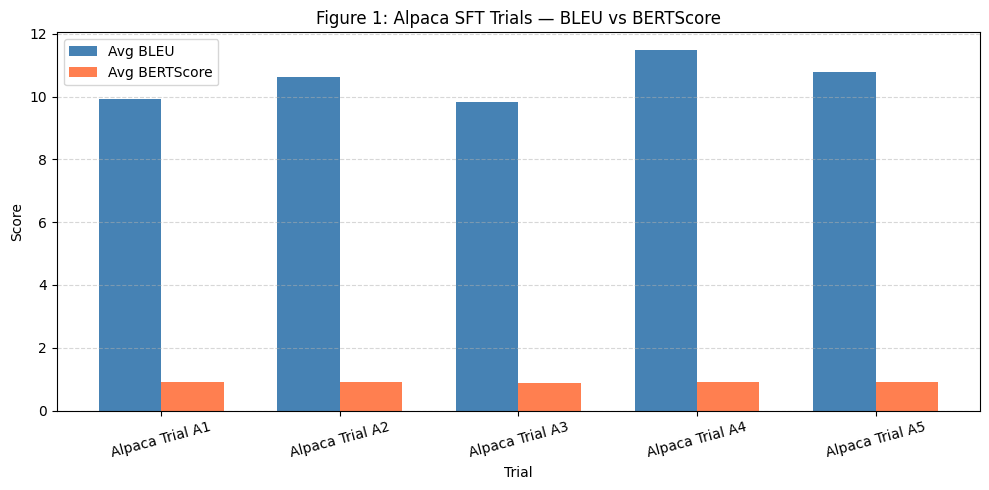

Saved as figure1_alpaca_scores.png


In [39]:
# FIGURE 1 — BLEU Scores Across All Alpaca Trials (Bar Chart)
import matplotlib.pyplot as plt

trials = [v["trial"] for v in alpaca_results.values()]
bleus = [v["avg_bleu"] for v in alpaca_results.values()]
berts = [v["avg_bert"] for v in alpaca_results.values()]

x = range(len(trials))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], bleus, width, label='Avg BLEU', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], berts, width, label='Avg BERTScore', color='coral')

ax.set_xlabel('Trial')
ax.set_ylabel('Score')
ax.set_title('Figure 1: Alpaca SFT Trials — BLEU vs BERTScore')
ax.set_xticks(list(x))
ax.set_xticklabels(trials, rotation=15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("figure1_alpaca_scores.png", dpi=150)
plt.show()
print("Saved as figure1_alpaca_scores.png")

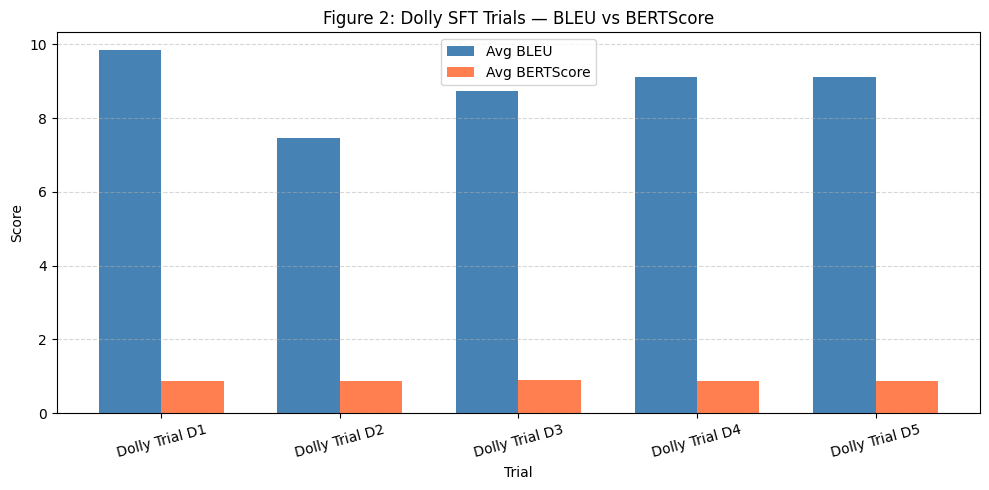

Saved as figure2_dolly_scores.png


In [40]:
# FIGURE 2 — BLEU Scores Across All Dolly Trials (Bar Chart)
trials_d = [v["trial"] for v in dolly_results.values()]
bleus_d = [v["avg_bleu"] for v in dolly_results.values()]
berts_d = [v["avg_bert"] for v in dolly_results.values()]

x = range(len(trials_d))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], bleus_d, width, label='Avg BLEU', color='steelblue')
ax.bar([i + width/2 for i in x], berts_d, width, label='Avg BERTScore', color='coral')

ax.set_xlabel('Trial')
ax.set_ylabel('Score')
ax.set_title('Figure 2: Dolly SFT Trials — BLEU vs BERTScore')
ax.set_xticks(list(x))
ax.set_xticklabels(trials_d, rotation=15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("figure2_dolly_scores.png", dpi=150)
plt.show()
print("Saved as figure2_dolly_scores.png")

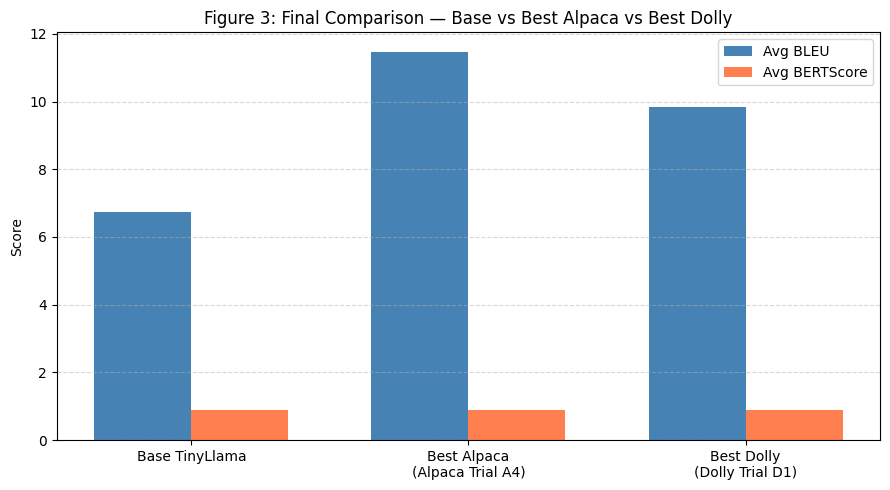

Saved as figure3_final_comparison.png


In [41]:
# FIGURE 3 — Final Comparison: Base vs Best Alpaca vs Best Dolly
models = ["Base TinyLlama", f"Best Alpaca\n({best_alpaca['trial']})", f"Best Dolly\n({best_dolly['trial']})"]

avg_bleu_base = round(sum(bleu_scores)/len(bleu_scores), 2)
avg_bert_base = round(sum(bert_scores)/len(bert_scores), 4)

final_bleus = [avg_bleu_base, best_alpaca["avg_bleu"], best_dolly["avg_bleu"]]
final_berts = [avg_bert_base, best_alpaca["avg_bert"], best_dolly["avg_bert"]]

x = range(len(models))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], final_bleus, width, label='Avg BLEU', color='steelblue')
ax.bar([i + width/2 for i in x], final_berts, width, label='Avg BERTScore', color='coral')

ax.set_ylabel('Score')
ax.set_title('Figure 3: Final Comparison — Base vs Best Alpaca vs Best Dolly')
ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("figure3_final_comparison.png", dpi=150)
plt.show()
print("Saved as figure3_final_comparison.png")

In [42]:
# TABLE 1 — Alpaca All Trials Summary Table
table1 = pd.DataFrame([{
    "Trial": v["trial"],
    "LoRA r": [4,8,16,32,64][i],
    "LR": ["2e-4","1e-4","2e-4","5e-5","1e-4"][i],
    "Batch": [4,8,4,16,8][i],
    "Epochs": [1,2,3,2,1][i],
    "Avg BLEU": v["avg_bleu"],
    "Avg BERTScore": v["avg_bert"]
} for i, v in enumerate(alpaca_results.values())])

print("Table 1: Alpaca SFT Trial Results")
print(table1.to_string(index=False))

Table 1: Alpaca SFT Trial Results
          Trial  LoRA r   LR  Batch  Epochs  Avg BLEU  Avg BERTScore
Alpaca Trial A1       4 2e-4      4       1      9.93         0.8946
Alpaca Trial A2       8 1e-4      8       2     10.62         0.8950
Alpaca Trial A3      16 2e-4      4       3      9.82         0.8880
Alpaca Trial A4      32 5e-5     16       2     11.47         0.8997
Alpaca Trial A5      64 1e-4      8       1     10.77         0.8964


In [43]:
# TABLE 2 — Dolly All Trials Summary Table
table2 = pd.DataFrame([{
    "Trial": v["trial"],
    "LoRA r": [4,8,16,32,64][i],
    "LR": ["2e-4","1e-4","2e-4","5e-5","1e-4"][i],
    "Batch": [4,8,4,16,8][i],
    "Epochs": [1,2,3,2,1][i],
    "Avg BLEU": v["avg_bleu"],
    "Avg BERTScore": v["avg_bert"]
} for i, v in enumerate(dolly_results.values())])

print("Table 2: Dolly SFT Trial Results")
print(table2.to_string(index=False))

Table 2: Dolly SFT Trial Results
         Trial  LoRA r   LR  Batch  Epochs  Avg BLEU  Avg BERTScore
Dolly Trial D1       4 2e-4      4       1      9.83         0.8857
Dolly Trial D2       8 1e-4      8       2      7.47         0.8882
Dolly Trial D3      16 2e-4      4       3      8.73         0.8935
Dolly Trial D4      32 5e-5     16       2      9.10         0.8859
Dolly Trial D5      64 1e-4      8       1      9.10         0.8891


In [44]:
# TABLE 3 — Per-Prompt Scores for Best Models (for report examples section)
table3 = pd.DataFrame({
    "Prompt": [p[:45]+"..." for p in prompts],
    "Base BLEU": bleu_scores,
    "Base BERT": bert_scores,
    "Best Alpaca BLEU": best_alpaca["bleu_scores"],
    "Best Alpaca BERT": best_alpaca["bert_scores"],
    "Best Dolly BLEU": best_dolly["bleu_scores"],
    "Best Dolly BERT": best_dolly["bert_scores"],
})

print("Table 3: Per-Prompt Score Breakdown")
print(table3.to_string(index=False))

Table 3: Per-Prompt Score Breakdown
                                          Prompt  Base BLEU  Base BERT  Best Alpaca BLEU  Best Alpaca BERT  Best Dolly BLEU  Best Dolly BERT
     Explain the water cycle in simple terms....      12.43     0.8706             10.15            0.8914             5.36           0.8836
Write a short email declining a meeting polit...       7.05     0.8783             20.54            0.9177            23.25           0.9131
 What are three benefits of regular exercise?...       1.88     0.8834             12.49            0.9184            15.48           0.9127
Summarize what the internet is in two sentenc...      20.44     0.9434             24.06            0.9333            20.74           0.9397
   Give five tips for better time management....       7.85     0.8988              9.65            0.9172             9.97           0.8981
What is the difference between a virus and a ...       5.00     0.8606              5.01            0.8871            

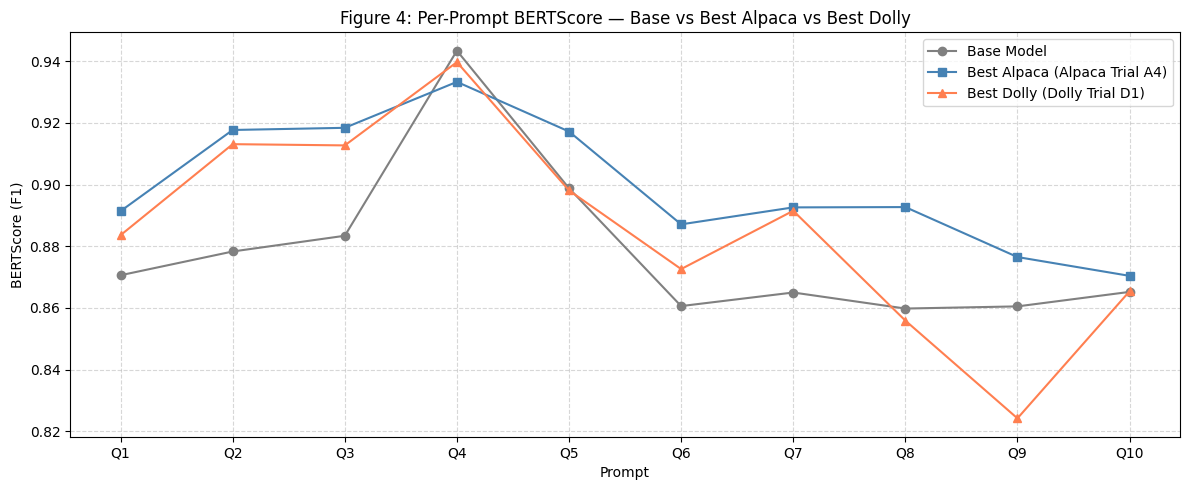

Saved as figure4_per_prompt_bert.png


In [45]:
# FIGURE 4 — Per-Prompt BERTScore Line Chart (Base vs Best Alpaca vs Best Dolly)
prompt_labels = [f"Q{i+1}" for i in range(10)]

plt.figure(figsize=(12, 5))
plt.plot(prompt_labels, bert_scores, marker='o', label='Base Model', color='gray')
plt.plot(prompt_labels, best_alpaca["bert_scores"], marker='s', label=f'Best Alpaca ({best_alpaca["trial"]})', color='steelblue')
plt.plot(prompt_labels, best_dolly["bert_scores"], marker='^', label=f'Best Dolly ({best_dolly["trial"]})', color='coral')

plt.xlabel('Prompt')
plt.ylabel('BERTScore (F1)')
plt.title('Figure 4: Per-Prompt BERTScore — Base vs Best Alpaca vs Best Dolly')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figure4_per_prompt_bert.png", dpi=150)
plt.show()
print("Saved as figure4_per_prompt_bert.png")

In [47]:
# QUALITATIVE EXAMPLES — Output Quality Section of Report
print("="*60)
print("QUALITATIVE COMPARISON — EXAMPLE OUTPUTS FOR REPORT")
print("="*60)

example_idx = 1  # Change this to see different prompts

print(f"\nPrompt: {prompts[example_idx]}")
print(f"\n--- Gold Answer (ChatGPT) ---\n{gold_answers[example_idx]}")
print(f"\n--- Base Model ---\n{base_responses[example_idx]}")
print(f"\n--- Best Alpaca Model ---\n{best_alpaca['responses'][example_idx]}")
print(f"\n--- Best Dolly Model ---\n{best_dolly['responses'][example_idx]}")

QUALITATIVE COMPARISON — EXAMPLE OUTPUTS FOR REPORT

Prompt: Write a short email declining a meeting politely.

--- Gold Answer (ChatGPT) ---
    
Subject: Unable to Attend Meeting    
Dear [Name],

Thank you for the invitation. Unfortunately, I won’t be able to attend the meeting due to a prior commitment.

I appreciate your understanding and hope we can connect another time.

Best regards,
[Your Name]


--- Base Model ---
Subject: Request for Rescheduling Meeting

Dear [Recipient],

I am writing to request a rescheduling of our upcoming meeting. As you are aware, I have a prior commitment that requires my immediate attention. I understand that this may cause inconvenience to you, but I kindly request that we reschedule the meeting for a mutually convenient time.

I apologize for any inconvenience this may cause, and I assure you that I will do my best to accommodate your schedule. Please let me know if there are any changes or adjustments that you would like to make to the meeting da